In [63]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

In [4]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [5]:
rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']


chains_runs = []
for dir in rundirs:
    chains_surveys = []
    for survey in survey_labels:
        chains = []
        for setup in setups:
            path = f"{base_dir}/inference/{dir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                s, l = utils.load_samples(path)
                chains.append(s)

        chains_surveys.append(chains)
    chains_runs.append(chains_surveys)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/SO-LAT/noiseless...
Load

In [6]:
rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

chains_surveys = []
for survey in survey_labels:
    chains = []
    for dir in rundirs[:2]:
        for setup in setups[2:]:
            path = f"{base_dir}/inference/{dir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                s, l = utils.load_samples(path)
                chains.append(s)

    chains_surveys.append(chains)


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/produ

In [7]:
true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
true_params

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[np.float64(-1.7166987712964503),
 np.float64(0.0),
 np.float64(3.277127671229863),
 np.float64(8.53),
 np.float64(0.275),
 np.float64(0.05526446348700878)]

In [8]:
s, l = utils.load_samples(f'{base_dir}/inference/productionruns3_justpriors/CMB-HD/noiseless')
s2, l = utils.load_samples(f'{base_dir}/inference/productionruns3_justpriors/CMB-HD/noiseless_Planck')
prior_samples = draws(10000)[:,2:]

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless_Planck...


In [82]:
s[:,:-1].shape

(82800, 3)

In [120]:
np.median(make_tauchains(s, truths=df.loc[config.sn].to_dict()), axis=0)

array([3.44275719, 8.80304885, 0.275294  , 0.0456661 ])

In [119]:
np.median(make_tauchains(s2, truths=df.loc[config.sn].to_dict()), axis=0)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


array([3.35644091, 8.82336569, 0.36768835, 0.05160604])

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


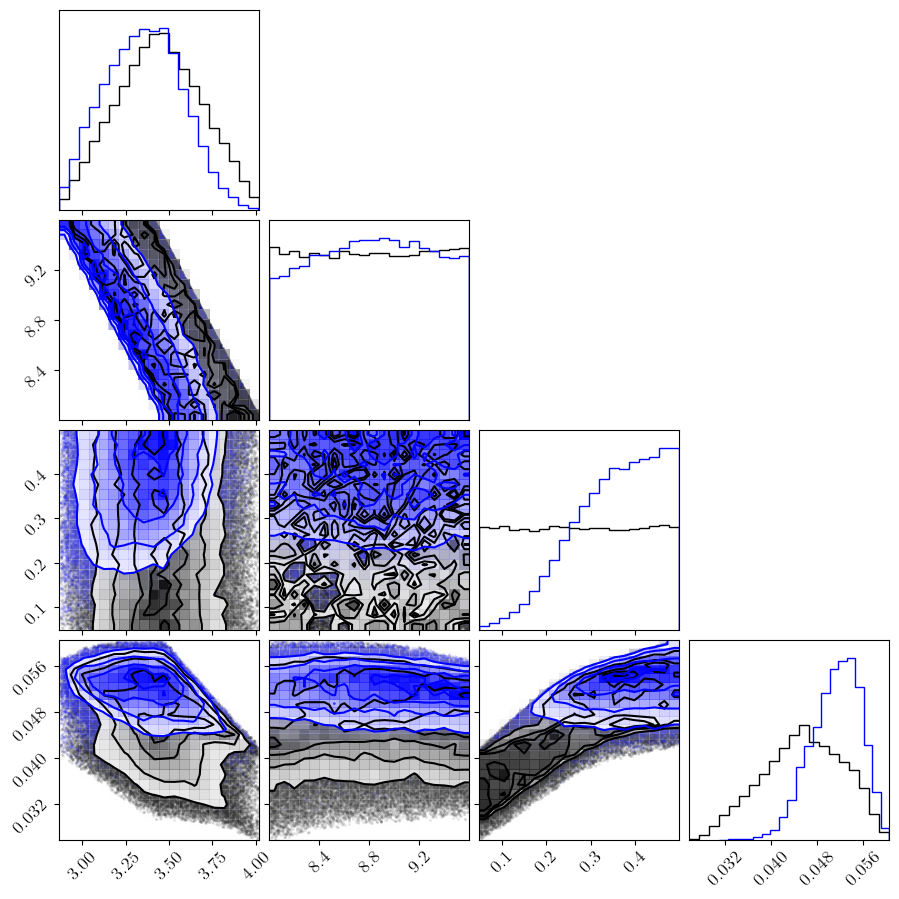

In [118]:
fig = corner.corner(make_tauchains(s, truths=df.loc[config.sn].to_dict()),
                    hist_kwargs={'density':True})
fig = corner.corner(make_tauchains(s2, truths=df.loc[config.sn].to_dict()),
                    fig=fig, hist_kwargs={'density':True}, color='blue')
# fig = corner.corner(make_tauchains(prior_samples, A=False, dropA=False, truths=df.loc[config.sn].to_dict()),
#                     fig=fig, hist_kwargs={'density':True}, color='red')

In [9]:
priors_s, _ = utils.load_samples("/Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless")
priors_s_Planck, _ = utils.load_samples("/Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless_Planck")

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless_Planck...


In [12]:
samples, l = utils.load_samples("/Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-HD/noiseless")
samples.shape

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-HD/noiseless...


(120000, 5)

In [15]:
priors_s[:,3:].shape

(120000, 1)

In [154]:
fill(samples, df.loc[config.sn].to_dict(), df.columns[2:])

array([[-1.71669877,  0.        ,  3.27058218,  8.60441348,  0.28536254],
       [-1.71669877,  0.        ,  3.47062074,  8.07901952,  0.30612696],
       [-1.71669877,  0.        ,  3.41764872,  8.15711561,  0.23908077],
       ...,
       [-1.71669877,  0.        ,  3.37619228,  8.38103679,  0.25679753],
       [-1.71669877,  0.        ,  3.20172203,  8.73903676,  0.2417857 ],
       [-1.71669877,  0.        ,  3.25269079,  8.73106227,  0.26111417]],
      shape=(120000, 5))

In [148]:
samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
samples_wtau.shape

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)

In [29]:
samples_wtau.shape

(120000, 4)

In [43]:
def make_fullsamples(samples):
    samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    full_samples = cp.deepcopy(np.concatenate([samples_wtau, samples[:,3:]], axis=1))

    return full_samples

nbins = 10
param_list = ['tau', 'Mmin', 'fesc', 'tau_CMB']
color_chains = ['black', 'red']
hist_kwargs = {'plot_datapoints': False,
              'levels': [0.393, 0.675, 0.864]}

# samples_wtau = make_tauchains(priors_s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
# histogram, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
# bin_centres = (bins[1:]+bins[:-1])/2.
# fig = corner.corner(samples_wtau, labels=param_list,
#                         bins=nbins, color='gray', **hist_kwargs)

# histogram, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
# bin_centres = (bins[1:]+bins[:-1])/2.

# fig = corner.corner(samples_wtau, labels=param_list, fig=fig,
#                         bins=nbins, weights=1./histogram, color='red', **hist_kwargs)


# for i, chain in enumerate([priors_s_Planck, samples[:, :-2]]):
#     samples_wtau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
#     histogram, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
#     bin_centres = (bins[1:]+bins[:-1])/2.
#     fig = corner.corner(samples_wtau, labels=param_list, fig=fig,
#                         bins=nbins, color=color_chains[i], **hist_kwargs)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_29992/3523832796.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


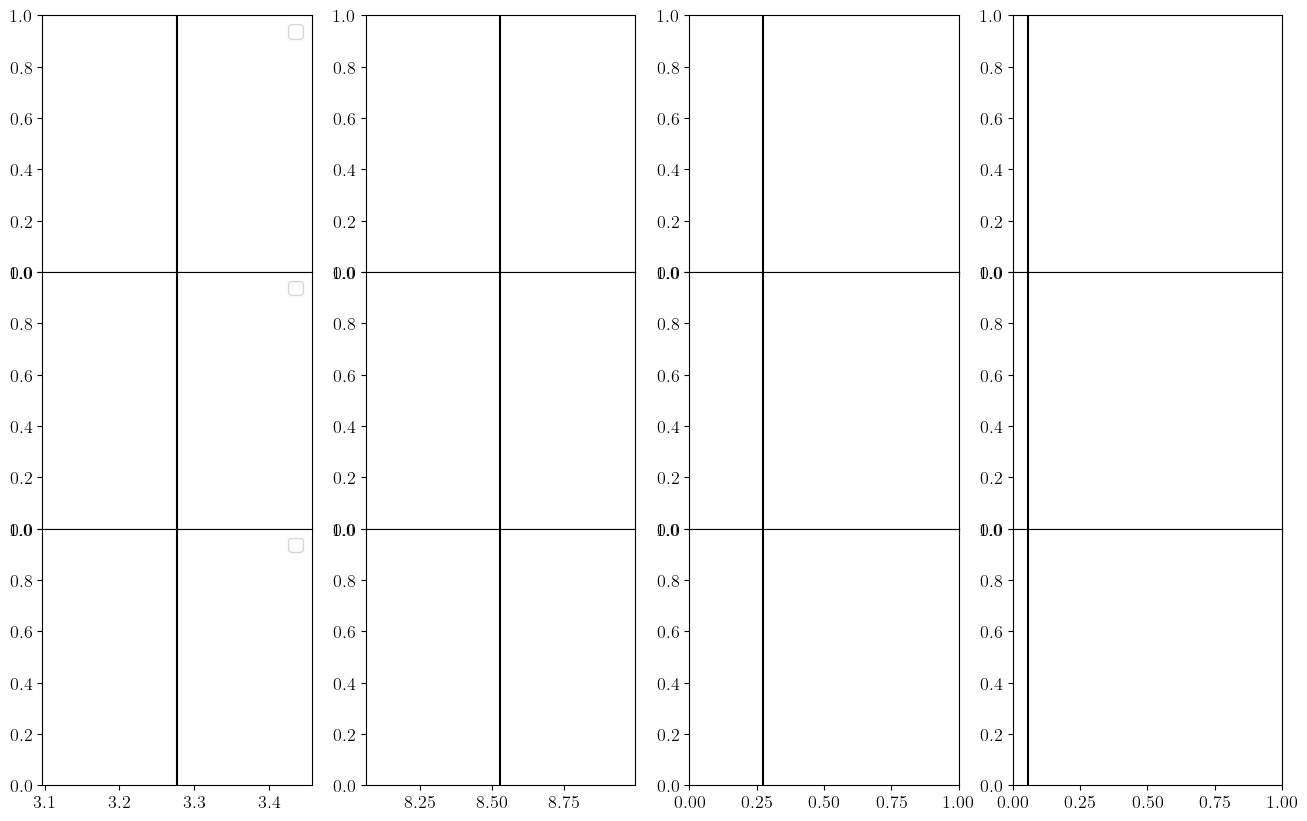

In [13]:
def make_fullsamples(samples):
    samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    full_samples = cp.deepcopy(np.concatenate([samples_wtau, samples[:,3:]], axis=1))

    return full_samples

nbins = 10
param_list = ['tau', 'Mmin', 'fesc', 'tau_CMB']
weights_labels = ['no weights', 'prior', 'Planck']
color_chains = ['black', 'red']
hist_kwargs = {'plot_datapoints': False,
              'levels': [0.393, 0.675, 0.864]}

true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]

fig, axes = plt.subplots(3,4, figsize=(16,10), sharex='col')
fig.subplots_adjust(hspace=0.0)

samples_wtau = make_tauchains(priors_s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=nbins)

bins_prior = cp.deepcopy(bins)
weights_prior = cp.deepcopy(counts)

samples_wtau = make_tauchains(priors_s_Planck[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=bins)

bins_Planck = cp.deepcopy(bins)
weights_Planck = cp.deepcopy(counts)

for ci, chain in enumerate([priors_s, priors_s_Planck, samples[:, :-2]]):
    samples_wtau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    for i, ax in enumerate(axes[ci]):
        ax.axvline(true_params[2+i], color='black')
        counts, bins = np.histogram(samples_wtau[:,i], bins=bins)

        # for j, weights in enumerate([np.ones_like(counts), weights_prior, weights_Planck]):
        #     w = np.interp(bins, bins_priors, 
        #     counts, bins, _ = ax.hist(bins[:-1], bins, weights=counts / weights, histtype='step', density=True, label=weights_labels[j])

        if i == 0:
            ax.legend()
# for i, chain in enumerate([priors_s_Planck, samples[:, :-2]]):
#     samples_wtau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
#     histogram, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
#     bin_centres = (bins[1:]+bins[:-1])/2.
#     fig = corner.corner(samples_wtau, labels=param_list, fig=fig,
#                         bins=nbins, color=color_chains[i], **hist_kwargs)


In [93]:
b

array([0.03094064, 0.03389873, 0.03685683, 0.03981492, 0.04277301,
       0.0457311 , 0.04868919, 0.05164729, 0.05460538, 0.05756347,
       0.06052156])

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


chain 0
bins [0.02572346 0.02688493 0.0280464  0.02920787 0.03036934 0.03153081
 0.03269228 0.03385375 0.03501522 0.03617669 0.03733816 0.03849962
 0.03966109 0.04082256 0.04198403 0.0431455  0.04430697 0.04546844
 0.04662991 0.04779138 0.04895285 0.05011432 0.05127579 0.05243726
 0.05359873 0.05476019 0.05592166 0.05708313 0.0582446  0.05940607
 0.06056754]
chains [ 0.31569209  1.00447482  2.79817985  6.07707265  9.70035681 13.40973881
 16.35141507 19.80967837 22.8518021  26.75490425 30.90195028 33.57098337
 38.48573515 42.67583011 46.987897   49.64975527 59.3214128  55.92054806
 50.25244016 47.96367254 46.40673657 44.08209485 40.60230709 38.34941357
 36.3619884  31.7629287  23.22489275 14.88057694  7.86360286  2.64033381]
counts Planck [1.00000000e-12 1.00000000e-12 1.00000000e-12 1.00000000e-12
 1.79370503e-02 2.69055755e-02 6.27796761e-02 1.07622302e-01
 3.49772481e-01 6.09859711e-01 1.49774370e+00 2.46634442e+00
 4.34973470e+00 7.56046671e+00 1.42868606e+01 2.13989010e+01
 3.60803

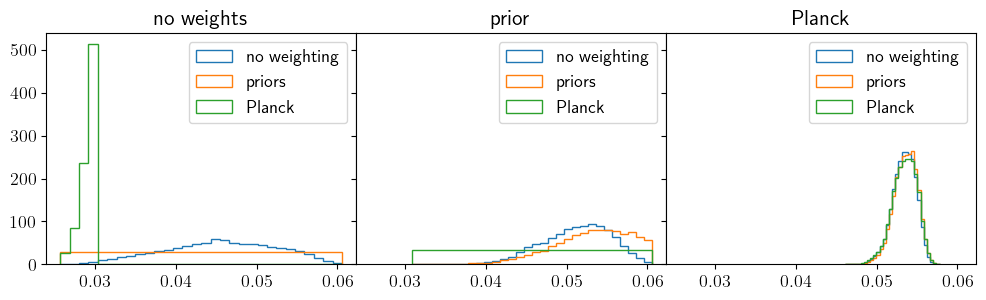

In [14]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(12,3))
fig.subplots_adjust(wspace=0.0)

nbins = 30
samples_wtau = make_tauchains(priors_s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
bins_prior = cp.deepcopy((bins[1:]+bins[:-1])/2.)
weights_prior = cp.deepcopy(counts)

samples_wtau = make_tauchains(priors_s_Planck[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=nbins)
bins_Planck = cp.deepcopy((bins[1:]+bins[:-1])/2.)
weights_Planck = cp.deepcopy(counts)


for ci, chain in enumerate([priors_s, priors_s_Planck, samples[:, :-2]]):
    print('===============')
    print(f'chain {ci}')
    print('===============')

    samples_wtau = make_tauchains(chain[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    counts, bins = np.histogram(samples_wtau[:,-1], bins=nbins, density=True)
    print(f"bins", bins)
    print(f"chains", counts)

    eps = 1e-12
    counts[counts == 0.0] = eps

    prior = make_tauchains(priors_s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    counts_prior, bins = np.histogram(prior[:,-1], bins=bins, density=True)

    prior_Planck = make_tauchains(priors_s_Planck[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
    counts_Planck, bins = np.histogram(prior_Planck[:,-1], bins=bins, density=True)

    eps = 1e-12
    counts_Planck[counts_Planck == 0.0] = eps

    print('counts Planck', counts_Planck)
    print()
    
    counts_samples, bins, _ = ax[ci].hist(bins[:-1], bins, weights=counts,
                                  histtype='step', density=True, label='no weighting')
    # print('counts den', counts)
    # print()
    
    counts, bins, _ = ax[ci].hist(bins[:-1], bins, weights=counts_samples / counts_prior, histtype='step',
                                  label='priors', density=True)
    # print('counts prior', counts)

    counts, bins, _ = ax[ci].hist(bins[:-1], bins, weights=counts_samples / counts_Planck, histtype='step',
                                  label='Planck', density=True)
    # print('counts Planck', counts)
    # print()
    ax[ci].legend()
    ax[ci].set_title(weights_labels[ci])

# samples_wtau = make_tauchains(priors_s_Planck[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
# counts, bins = np.histogram(samples_wtau[:,-1], bins=bins)
# weights_Planck = cp.deepcopy(counts)
# print(bins)

In [57]:
samples_wtau = make_tauchains(priors_s_Planck[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=nbins)

(array([1.2000e+01, 1.3800e+02, 1.0970e+03, 4.1820e+03, 1.3116e+04,
        2.9373e+04, 3.6619e+04, 2.8120e+04, 7.0000e+03, 3.4300e+02]),
 array([0.04606921, 0.04724058, 0.04841194, 0.0495833 , 0.05075466,
        0.05192603, 0.05309739, 0.05426875, 0.05544012, 0.05661148,
        0.05778284]),
 <BarContainer object of 10 artists>)

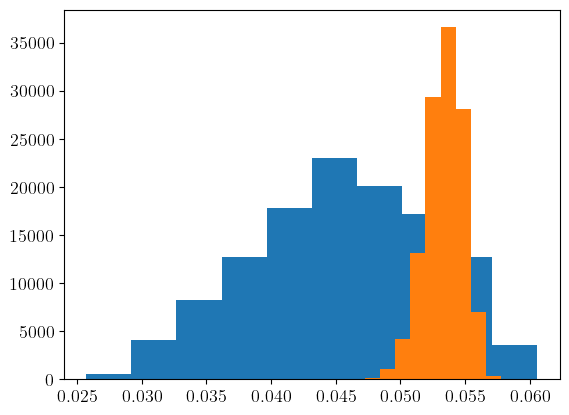

In [56]:
plt.hist(prior[:,-1])
plt.hist(samples_wtau[:,-1])

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/SO-LAT/noiseless...


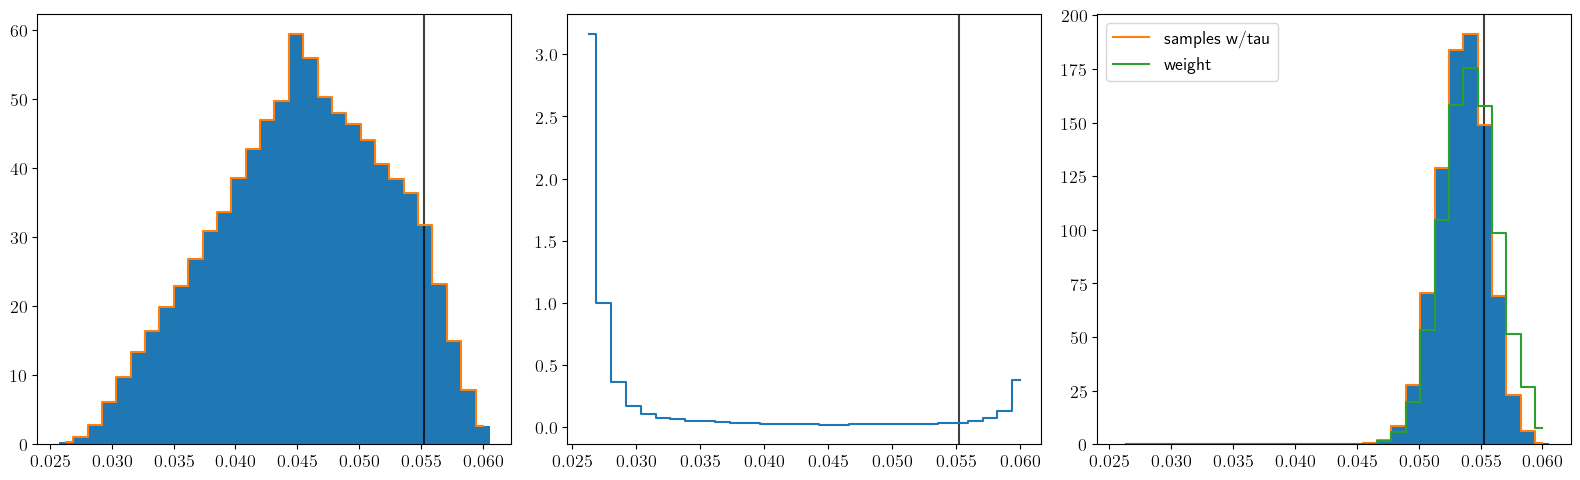

In [65]:
fig, ax = plt.subplots(1,3, figsize=(16,5))

[ax[i].axvline(whatthetau(df.loc[config.sn].to_numpy()), color='black', alpha=.75) for i in range(3)]

prior = make_tauchains(priors_s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts_prior, bins = np.histogram(prior[:,-1], bins=nbins, density=True)

samples, l = utils.load_samples("/Users/emcbride/Datasets/LoReLi/inference/productionruns7_addhksz/SO-LAT/noiseless")

samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
counts, bins = np.histogram(samples_wtau[:,-1], bins=bins, density=True)
# print(f"bins", bins)
# print(f"chains", counts)

eps = 1e-12
counts[counts == 0.0] = eps

bin_centers = 0.5 * (bins[1:] + bins[:-1])

ax[0].hist(prior[:,-1], density=True, bins=bins)

ax[0].plot(bin_centers, counts_prior, ds='steps-mid')

weights = interp1d(bin_centers, 1/counts_prior, fill_value='extrapolate', bounds_error=False)
ax[1].plot(bin_centers, weights(bin_centers), ds='steps-mid')
# ax[1].plot(bin_centers, 1 / counts_prior, ds='steps-mid')

ax[2].hist(samples_wtau[:,-1], density=True, bins=bins)
ax[2].plot(bin_centers, counts, ds='steps-mid', label='samples w/tau')
# ax[2].plot(bin_centers, counts / counts_prior, ds='steps-mid', label='samples w/ weights')

from scipy.interpolate import interp1d



counts_flattened, bins = np.histogram(
    samples_wtau[:,-1],
    weights=weights(samples_wtau[:,-1]), bins=bins, density=True
)
ax[2].plot(bin_centers, counts_flattened, ds='steps-mid', label='weight')

ax[2].legend()
fig.tight_layout()

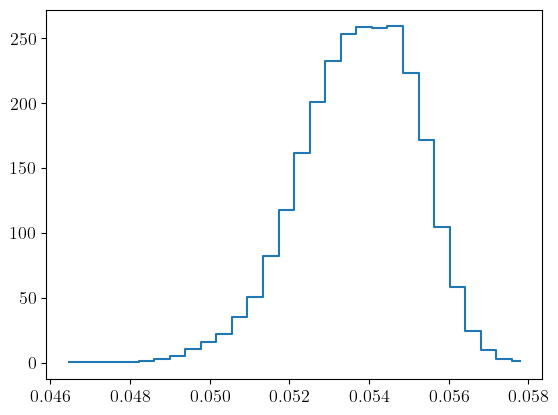

In [40]:
plt.plot(bins[1:], counts_flattened, ds='steps-mid')

In [ ]:
bin_centres = (bins[1:]+bins[:-1])/2.
# remove empty bins as the value cannot be inverted (1/0=infinity)
histogram[histogram==0.] = histogram[histogram>0.][0]

In [70]:
import pandas as pd

rundirs = ['productionruns6_addhksz',
            'productionruns7_addhksz']

survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT', 'priors']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

rows = []
#chains_runs = []
pnames = [*df.columns[2:], 'tau_CMB', 'A_bias', 'A_hksz']
for idir, rundir in enumerate(rundirs):
    # print(rundir)
   # chains_surveys = []
    for isur, survey in enumerate(survey_labels):
     #   chains = []
        for iset, setup in enumerate(setups):
            if survey == 'priors':
                path = f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/{setup}"
            else:
                path = f"{base_dir}/inference/{rundir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
           #     print(f"On run {rundir}, survey {survey}, with setup {setup}")
                samples, l = utils.load_samples(path)
                samples_wtau = make_tauchains(samples[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
                full_samples = np.concatenate([samples_wtau, samples[:,3:]], axis=1)

                print(f"full samples shape is {full_samples.shape}")
                print()
                for i in range(full_samples.shape[0]):  # iterate over rows (samples)
                    for dim_idx in range(full_samples.shape[1]):  # iterate over columns
                        # print(f"samples shape is {samples[i, dim_idx].shape}")
                        # if i % 1000 == 0:
                        #     print(f"dim_idx = {dim_idx}, param = {pnames[dim_idx]}, value = {full_samples[i, dim_idx]}")
                        rows.append({
                            "value": full_samples[i, dim_idx],
                            "parameter": pnames[dim_idx],
                            "rundir": rundir,
                            "survey": survey,
                            "setup": setup,
                         #   "sample_index": i  # optional
                        })

df_samples = pd.DataFrame(rows)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-HD/noiseless...


<string>:38: RuntimeWarning: divide by zero encountered in log10


full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-HD/noiseless_Planck...
full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-S4/noiseless...
full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/CMB-S4/noiseless_Planck...
full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/SO-LAT/noiseless...
full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_addhksz/SO-LAT/noiseless_Planck...
full samples shape is (120000, 6)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless...
full samples shape is (120000, 5)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors

In [8]:
df_samples['parameter'].unique(), pnames[dim_idx]

(array(['tau', 'Mmin', 'fesc', 'tau_CMB', 'A'], dtype=object), 'tau_CMB')

<ErrorbarContainer object of 3 artists>

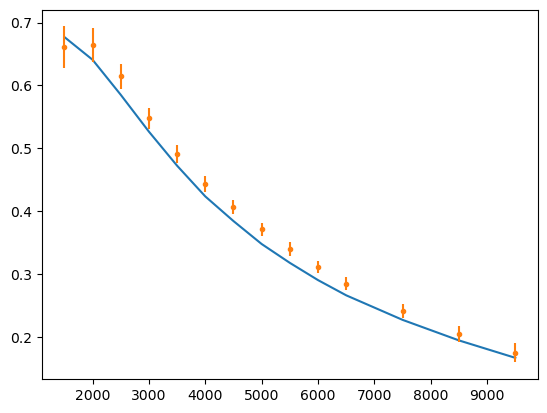

In [41]:
data = np.load(f'{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz', allow_pickle=True)

plt.plot(data['ells'], data['model'])
plt.errorbar(data['ells'], data['datapoints'], yerr=data['err'], marker='.', ls='')

0, CMB-HD
0, tau
0, CMB-HD
1, Mmin
0, CMB-HD
2, fesc
0, CMB-HD
3, tau_CMB
1, CMB-S4
0, tau
1, CMB-S4
1, Mmin
1, CMB-S4
2, fesc
1, CMB-S4
3, tau_CMB
2, SO-LAT
0, tau


AttributeError: 'NoneType' object has no attribute 'remove'

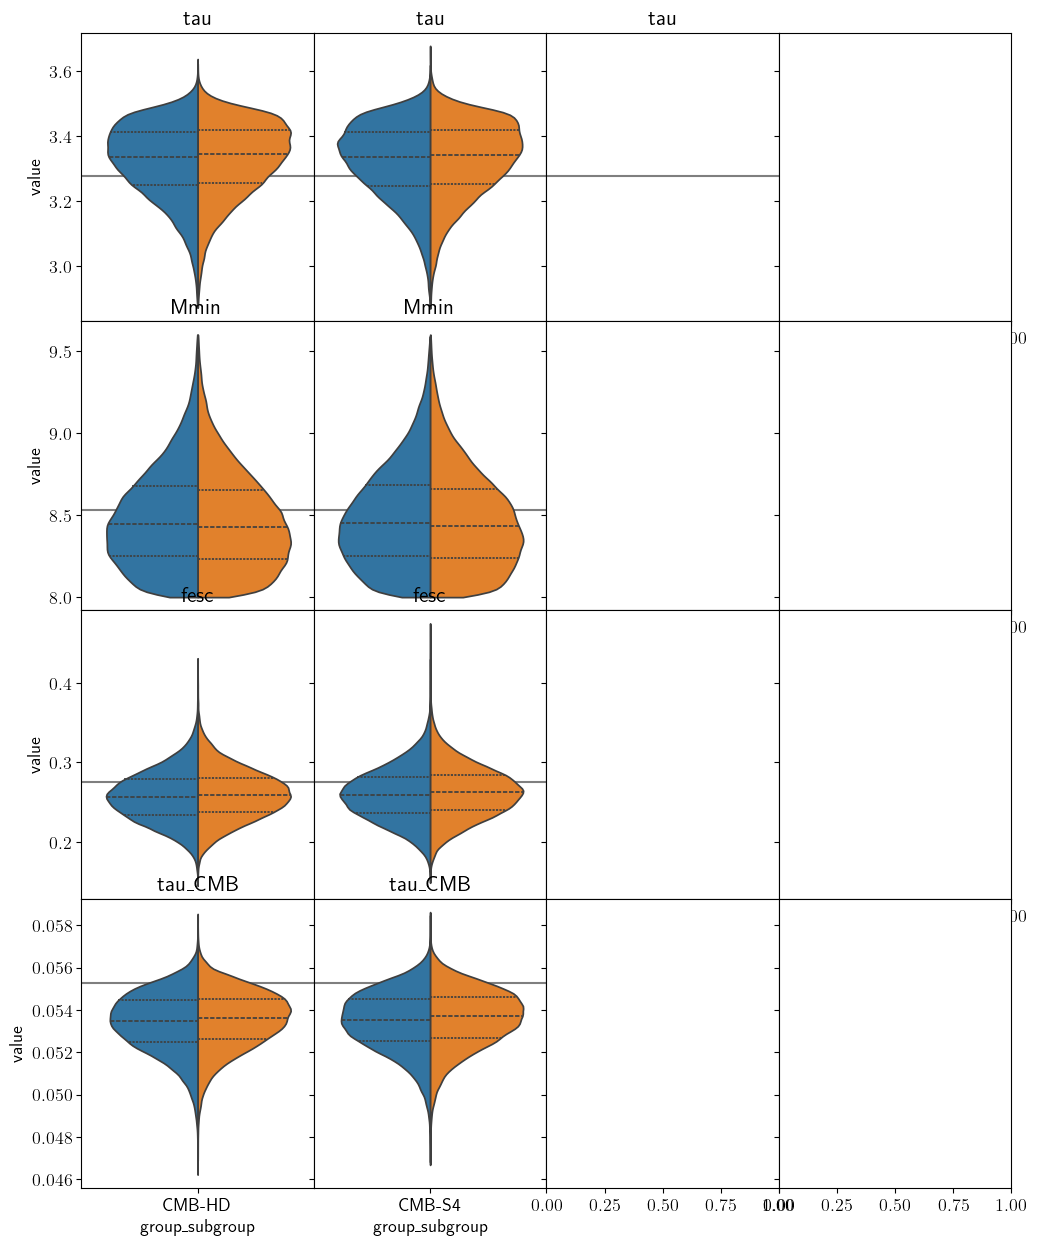

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(4, 4, figsize=(12, 15), sharex=False, sharey='row')
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i_survey, survey in enumerate(survey_labels):
    for i_param, param in enumerate(dim_labels):
        print(f"{i_survey}, {survey}")
        print(f"{i_param}, {param}")

        ax = axs[i_param, i_survey]
        ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
        # Filter to only the two main groups
        df_subset = df_samples[
            (df_samples["parameter"] == param) &
            (df_samples["rundir"] == 'productionruns7_addhksz') &
            (df_samples["survey"] == survey) &
            # (df_samples["setup"] == 'noiseless')
           (df_samples["setup"].isin(setups[2:]))
        ].copy()
    
        # Create a new column for combined group/subgroup label
        df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
        # Plot each group_subgroup as a separate category on the x-axis
        sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
                       inner='quart', hue="setup", x="group_subgroup", y="value", ax=ax)
        ax.set_title(param)
        ax.get_legend().remove()

for i_param, param in enumerate(dim_labels):
    print(f"{i_survey}, {survey}")
    # print(f"{i_param}, {param}")

    ax = axs[i_param, i_survey+1]
    ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
    # Filter to only the two main groups
    df_subset = df_samples[
        (df_samples["parameter"] == param) &
        (df_samples["rundir"] == 'productionruns7_addhksz') &
        (df_samples["survey"] == 'CMB-HD') &
        (df_samples["setup"].isin(['noiseless_priors', 'noiseless_Planck_priors']))
#       (df_samples["setup"] == 'CMB-HD_priors')
    ].copy()

    # Create a new column for combined group/subgroup label
    df_subset["group_subgroup"] = 'priors' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
    
    # Plot each group_subgroup as a separate category on the x-axis
    sns.violinplot(data=df_subset, hue="setup", split=True, common_norm=True, cut=0,
                   inner='quart', x="group_subgroup", y="value", ax=ax)
    ax.set_title(param)
    ax.get_legend().remove()

plt.tight_layout()
plt.savefig("violins.png", dpi=300, bbox_inches='tight')


In [72]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# fig = plt.figure(figsize=(10, 6))
# subfigs = fig.subfigures(1, 2, wspace=0.0)

# axs = subfigs[0].subplots(2, 4, sharey='row')
# subfigs[0].subplots_adjust(wspace=0.0)
# subfigs[1].subplots_adjust(wspace=0)

# sn = config.sn
# true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]

# for i_survey, survey in enumerate(survey_labels):
#     for i_param, param in enumerate(dim_labels[:2]):
#         print(f"{i_survey}, {survey}")
#         # print(f"{i_param}, {param}")

#         ax = axs[i_param, i_survey]
#         ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
#         # Filter to only the two main groups
#         df_subset = df_samples[
#             (df_samples["parameter"] == param) &
#             (df_samples["rundir"] == 'productionruns5_mechaemu') &
#             (df_samples["survey"] == survey) &
#             # (df_samples["setup"] == 'noiseless')
#            (df_samples["setup"].isin(setups[:2]))
#         ].copy()
    
#         # Create a new column for combined group/subgroup label
#         df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
#         # Plot each group_subgroup as a separate category on the x-axis
#         sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
#                        inner='quart', hue="setup", x="group_subgroup", y="value", ax=ax)

#         ax.set_xlabel('')
#         ax.set_ylabel('')

#         if i_param == 0:
#             ax.set_title(f"{survey}")
#         ax.set_title(param)
#         ax.get_legend().remove()

# for i_param, param in enumerate(dim_labels[:2]):
#     # print(f"{i_survey}, {survey}")
#     # print(f"{i_param}, {param}")

#     ax = axs[i_param, i_survey+1]
#     ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
#     # Filter to only the two main groups
#     df_subset = df_samples[
#         (df_samples["parameter"] == param) &
#         (df_samples["rundir"] == 'productionruns2_mechaemu') &
#         (df_samples["survey"] == 'CMB-HD') &
#         (df_samples["setup"].isin(['noiseless_priors', 'noiseless_Planck_priors']))
# #       (df_samples["setup"] == 'CMB-HD_priors')
#     ].copy()

#     # Create a new column for combined group/subgroup label
#     df_subset["group_subgroup"] = 'priors' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
    
#     # Plot each group_subgroup as a separate category on the x-axis
#     sns.violinplot(data=df_subset, hue="setup", split=True, common_norm=True, cut=0,
#                    inner='quart', x="group_subgroup", y="value", ax=ax)

#     ax.set_xlabel('')
#     ax.set_ylabel('')

#     if i_param == 0:
#         ax.set_title(f"{survey}")
#     ax.get_legend().remove()

# axs = subfigs[1].subplots(2, 4, sharey='row')

# for i_survey, survey in enumerate(survey_labels):
#     for i_param, param in enumerate(dim_labels[2:]):
#         print(f"{i_survey}, {survey}")
#         # print(f"{i_param}, {param}")

#         ax = axs[i_param, i_survey]
#         ax.axhline(true_params[4+i_param], color='black', alpha=.5, zorder=0)
#         # Filter to only the two main groups
#         df_subset = df_samples[
#             (df_samples["parameter"] == param) &
#             (df_samples["rundir"] == 'productionruns5_mechaemu') &
#             (df_samples["survey"] == survey) &
#             # (df_samples["setup"] == 'noiseless')
#            (df_samples["setup"].isin(setups[:2]))
#         ].copy()
    
#         # Create a new column for combined group/subgroup label
#         df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
#         # Plot each group_subgroup as a separate category on the x-axis
#         sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
#                        inner='quart', hue="setup", x="group_subgroup", y="value", ax=ax)
#         ax.set_xlabel('')
#         ax.set_ylabel('')
    
#         if i_param == 0:
#             ax.set_title(f"{survey}")
#         ax.get_legend().remove()

# for i_param, param in enumerate(dim_labels[2:]):
#     print(f"{i_survey}, {survey}")
#     # print(f"{i_param}, {param}")

#     ax = axs[i_param, i_survey+1]
#     ax.axhline(true_params[4+i_param], color='black', alpha=.5, zorder=0)
#     # Filter to only the two main groups
#     df_subset = df_samples[
#         (df_samples["parameter"] == param) &
#         (df_samples["rundir"] == 'productionruns2_mechaemu') &
#         (df_samples["survey"] == 'CMB-HD') &
#         (df_samples["setup"].isin(['noiseless_priors', 'noiseless_Planck_priors']))
# #       (df_samples["setup"] == 'CMB-HD_priors')
#     ].copy()

#     # Create a new column for combined group/subgroup label
#     df_subset["group_subgroup"] = 'priors' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
    
#     # Plot each group_subgroup as a separate category on the x-axis
#     sns.violinplot(data=df_subset, hue="setup", split=True, common_norm=True, cut=0,
#                    inner='quart', x="group_subgroup", y="value", ax=ax)
#     ax.set_xlabel('')
#     ax.set_ylabel('')

#     if i_param == 0:
#         ax.set_title(f"{survey}")
#     ax.get_legend().remove()

# # plt.tight_layout()
# # plt.savefig("violins.png", dpi=300, bbox_inches='tight')


In [54]:
df_samples

,value,parameter,rundir,survey,setup,sample_index,sample_id
0,3.136883,tau,productionruns2_mechaemu,CMB-HD,noiseless,0,0
1,9.084696,Mmin,productionruns2_mechaemu,CMB-HD,noiseless,0,0
2,0.237093,fesc,productionruns2_mechaemu,CMB-HD,noiseless,0,0
3,0.051118,tau_CMB,productionruns2_mechaemu,CMB-HD,noiseless,0,0
4,1.106927,A,productionruns2_mechaemu,CMB-HD,noiseless,0,0
...,...,...,...,...,...,...,...
22535995,3.051905,tau,productionruns6_addhksz,priors,noiseless_Planck,95999,3755999
22535996,9.251506,Mmin,productionruns6_addhksz,priors,noiseless_Planck,95999,3755999
22535997,0.488103,fesc,productionruns6_addhksz,priors,noiseless_Planck,95999,3755999
22535998,0.057469,tau_CMB,productionruns6_addhksz,priors,noiseless_Planck,95999,3755999


In [62]:
chosen_rundir = "productionruns7_addhksz"
chosen_setup = "noiseless"

# Filter
df_filtered = df_samples[
    (df_samples['rundir'] == chosen_rundir) &
    (df_samples['setup'] == chosen_setup)
]

In [65]:
df_filtered

,value,parameter,rundir,survey,setup
17136000,3.270582,tau,productionruns6_addhksz,CMB-HD,noiseless
17136001,8.604413,Mmin,productionruns6_addhksz,CMB-HD,noiseless
17136002,0.285363,fesc,productionruns6_addhksz,CMB-HD,noiseless
17136003,0.055050,tau_CMB,productionruns6_addhksz,CMB-HD,noiseless
17136004,1.032797,A,productionruns6_addhksz,CMB-HD,noiseless
...,...,...,...,...,...
22055995,3.439310,tau,productionruns6_addhksz,priors,noiseless
22055996,8.716616,Mmin,productionruns6_addhksz,priors,noiseless
22055997,0.499530,fesc,productionruns6_addhksz,priors,noiseless
22055998,0.053685,tau_CMB,productionruns6_addhksz,priors,noiseless


In [79]:
print(df_sub.shape)
print(df_sub['rundir'].unique())
print(df_sub['setup'].unique())
print(df_sub['survey'].unique())
print(df_sub['parameter'].unique())


(2160000, 6)
['productionruns6_addhksz']
['noiseless']
['CMB-HD' 'CMB-S4' 'SO-LAT']
['tau' 'Mmin' 'fesc' 'tau_CMB' 'A' 'A_hksz']


In [80]:
print(df_wide.shape)
print(df_wide.columns)


(2160000, 8)
Index(['sample_idx', 'survey', 'A', 'A_hksz', 'Mmin', 'fesc', 'tau',
       'tau_CMB'],
      dtype='object', name='parameter')


In [81]:
param_list = ['tau', 'Mmin', 'fesc', 'tau_CMB', 'A']
missing = [p for p in param_list if p not in df_wide.columns]
if missing:
    print("Missing parameters:", missing)


In [73]:
df_sub = df_samples[
    (df_samples['rundir'] == 'productionruns7_addhksz') &
    (df_samples['setup'] == 'noiseless') &
    (df_samples['survey'] != 'priors')  # exclude 'priors'
].copy()


In [76]:
df_sub['sample_idx'] = df_sub.index

In [77]:
df_wide = df_sub.pivot(
    index=['sample_idx', 'survey'],
    columns='parameter',
    values='value'
).reset_index()


In [96]:
# df_sub = df_samples[
#     (df_samples['rundir'] == 'productionruns6_addhksz') &
#     (df_samples['setup'] == 'noiseless')
# ].copy()

# if df_sub.empty:
#     raise ValueError("Filtered dataframe is empty!")

# df_sub['sample_idx'] = df_sub.index

# df_wide = df_sub.pivot(index=['sample_idx', 'survey'], columns='parameter', values='value').reset_index()

# param_list = ['tau', 'Mmin', 'fesc', 'tau_CMB', 'A']
# param_list = [p for p in param_list if p in df_wide.columns]

# if not param_list:
#     raise ValueError("No parameters found to plot!")

# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.pairplot(
#     df_wide,
#     hue='survey',
#     vars=pnames,
#     kind='kde',        # or 'scatter', 'hist', etc.
#     diag_kind='kde',
#     corner=True,
#     plot_kws={'alpha': 0.2})
# plt.show()


In [69]:
samples

array([], dtype=float64)

In [100]:
true_values = dict(zip(pnames, [*true_params[2:], 1.042532116516509, 2.9]))

results = []

for i_survey, survey in enumerate(survey_labels[:-1]):
    for j_param, param in enumerate(pnames):
        print(f"For {survey} and param={param}")
        df_subset = df_samples[
        (df_samples["parameter"] == param) &
        (df_samples["rundir"] == 'productionruns7_addhksz') &
        (df_samples["survey"] == survey) &
        (df_samples["setup"] == 'noiseless')].copy()

        samples = df_subset["value"].to_numpy()
        
        # Posterior median
        median_val = np.median(samples)
        
        # 68% credible interval (asymmetric)
        low, high = np.percentile(samples, [16, 84])
        low_err = median_val - low
        high_err = high - median_val
        
        # Bias and normalized bias
        
        bias = median_val - true_values[param]

        if param == 'Mmin':
            print(f"median_val for {survey} is {median_val}")
            print(f"true_val for {survey} is {true_values[param]}")
            print(f"bias for {survey} is {bias}")

        if bias <= 0.0:
            sigma_bias = low_err

        elif bias > 0.0:
            sigma_bias = high_err
        
        if param == 'Mmin':
            print(sigma_bias)
            
        # sigma_68_sym = 0.5 * (high - low)  # for bias/σ, use symmetric approx
        bias_over_sigma = bias / sigma_bias # sigma_68_sym
        
        results.append({
            "survey": survey,
            "parameter": param,
  #          "true": true_values[param],
            "median": median_val,
   #         "low68": low,
   #         "high68": high,
            "low_err": low_err,
            "high_err": high_err,
            "CI68": high - low,
           "bias": bias,
            "bias_over_sigma": bias_over_sigma,
            "frac_uncertainty": 100 * (high-low) / median_val
        })

    print()

# Convert to DataFrame
df_results = pd.DataFrame(results)
print(df_results)

For CMB-HD and param=tau
For CMB-HD and param=Mmin
median_val for CMB-HD is 8.445982144971923
true_val for CMB-HD is 8.53
bias for CMB-HD is -0.08401785502807613
0.27696636391863727
For CMB-HD and param=fesc
For CMB-HD and param=tau_CMB
For CMB-HD and param=A_bias
For CMB-HD and param=A_hksz

For CMB-S4 and param=tau
For CMB-S4 and param=Mmin
median_val for CMB-S4 is 8.457324085888029
true_val for CMB-S4 is 8.53
bias for CMB-S4 is -0.07267591411197039
0.2798201345413087
For CMB-S4 and param=fesc
For CMB-S4 and param=tau_CMB
For CMB-S4 and param=A_bias
For CMB-S4 and param=A_hksz

For SO-LAT and param=tau
For SO-LAT and param=Mmin
median_val for SO-LAT is 8.688892923637212
true_val for SO-LAT is 8.53
bias for SO-LAT is 0.15889292363721275
0.525266805962703
For SO-LAT and param=fesc
For SO-LAT and param=tau_CMB
For SO-LAT and param=A_bias
For SO-LAT and param=A_hksz

    survey parameter    median   low_err  high_err      CI68      bias  \
0   CMB-HD       tau  3.337883  0.133534  0.1054

In [103]:
def round_sig(x, sig=3):
    """Round to `sig` significant figures."""
    if pd.isnull(x):
        return x
    try:
        return float(f"{x:.{sig}g}")
    except (ValueError, TypeError):
        return x  # leave non-numerics untouched

# Apply only to numeric columns
numeric_cols = df_results.select_dtypes(include=[np.number]).columns
df_results[numeric_cols] = df_results[numeric_cols].applymap(lambda v: round_sig(v, sig=3))


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_29992/975883094.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_results[numeric_cols] = df_results[numeric_cols].applymap(lambda v: round_sig(v, sig=3))


In [104]:
for pname in pnames:
    print()
    print('--------------------')
    print(f"PARAM: {pname}")
    print()
    print('--------------------')
    print(df_results[df_results['parameter'] == pname])


--------------------
PARAM: tau

--------------------
    survey parameter  median  low_err  high_err   CI68    bias  \
0   CMB-HD       tau    3.34    0.134     0.105  0.239  0.0608   
6   CMB-S4       tau    3.33    0.136     0.107  0.243  0.0572   
12  SO-LAT       tau    3.31    0.213     0.168  0.380  0.0357   

    bias_over_sigma  frac_uncertainty  
0             0.576              7.16  
6             0.533              7.29  
12            0.213             11.50  

--------------------
PARAM: Mmin

--------------------
    survey parameter  median  low_err  high_err   CI68    bias  \
1   CMB-HD      Mmin    8.45    0.277     0.339  0.616 -0.0840   
7   CMB-S4      Mmin    8.46    0.280     0.344  0.624 -0.0727   
13  SO-LAT      Mmin    8.69    0.448     0.525  0.973  0.1590   

    bias_over_sigma  frac_uncertainty  
1            -0.303              7.29  
7            -0.260              7.38  
13            0.302             11.20  

--------------------
PARAM: fesc

----

In [1]:
(2 * 0.00151), (2 * 0.00135)

(0.00302, 0.0027)

In [2]:
(2 * 0.00154), (2 * 0.00136) 0.00207   0.00190

(0.00308, 0.00272)

In [4]:
(2 * 0.00207), (2 * 0.00190)

(0.00414, 0.0038)

In [3]:
.0265 + .0264, .0190 + .0151

(0.0529, 0.0341)

/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_65967/1445747756.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  [subf.subplots_adjust(wspace=0.0) for subf in subfigs.flatten()]
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


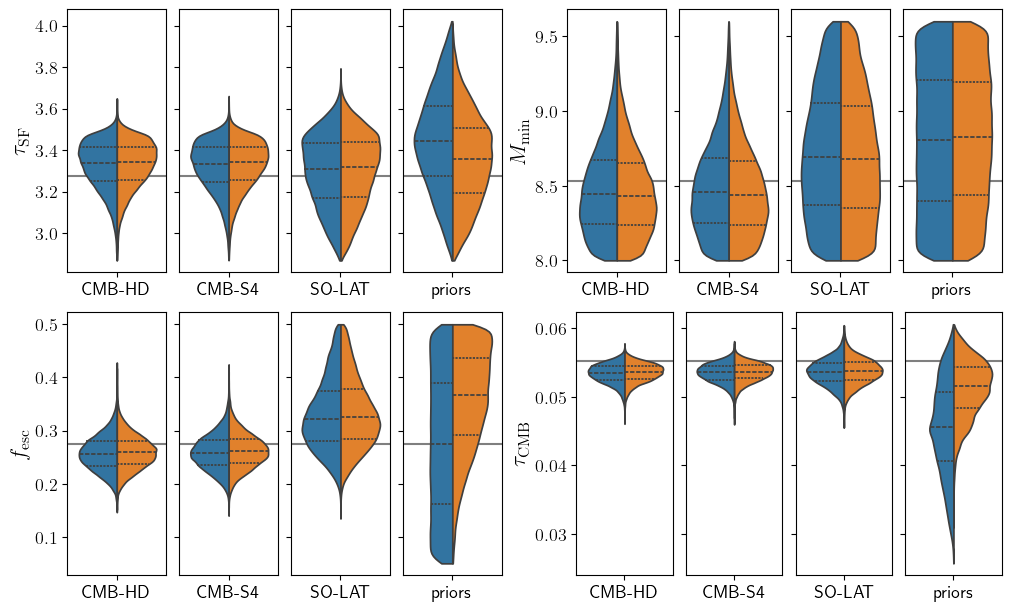

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6), constrained_layout=True)
subfigs = fig.subfigures(2, 2, wspace=0.0)
[subf.subplots_adjust(wspace=0.0) for subf in subfigs.flatten()]
# subfigs[1].subplots_adjust(wspace=0)

sn = config.sn
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]

def plot_violins(axs, df, pname, pval, xlabel=None):
    for i_survey, survey in enumerate(survey_labels):
        # if xlabel != None:
        #     xlabel = survey
        
        ax = axs[i_survey]
        ax.axhline(pval, color='black', alpha=.5, zorder=0)
        # Filter to only the two main groups
        df_subset = df_samples[
            (df_samples["parameter"] == pname) &
            (df_samples["rundir"] == 'productionruns6_addhksz') &
            (df_samples["survey"] == survey) &
            # (df_samples["setup"] == 'noiseless')
           (df_samples["setup"].isin(setups[:2]))
        ].copy()
    
        # Create a new column for combined group/subgroup label
        df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
        # Plot each group_subgroup as a separate category on the x-axis
        sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
                       inner='quart', hue="setup", x="group_subgroup", y="value", ax=ax)

        ax.set_xlabel(None)
        ax.set_ylabel('')

        # if i_param == 0:
        #     ax.set_title(f"{survey}")
        ax.set_ylabel(astro_pnames_formatted[2+i], fontsize=16)
        ax.get_legend().remove()

subfigs = subfigs.flatten()
for i, pname in enumerate(dim_labels):
    axs = subfigs[i].subplots(1, 4, sharey='row')
    xlabel = None
    if i > 1:
        xlabel = 'survey'
    plot_violins(axs, df, pname, true_params[2+i])

# plt.tight_layout()
plt.savefig("violins.png", dpi=300, bbox_inches='tight')


In [ ]:
# Your data setup
min_n = df_wide['label'].value_counts().min()
df_balanced = df_wide.groupby('label').sample(n=min_n, random_state=42)

# Your true values
true_vals = [*df.loc[config.sn].to_numpy(), whatthetau(df.loc[config.sn].to_numpy())]

# Choose parameters (assumes they start from col index 2)
params = df_wide.columns[2:]

# Create the pairplot
g = sns.pairplot(df_balanced, vars=[*df.columns[2:], 'tau_CMB'], hue='label', corner=True,
                 diag_kind='kde', kind='kde', plot_kws={"levels": 3})

# Add vertical lines to the diagonal plots
for i, param in enumerate([*df.columns[2:], 'tau_CMB']):
    ax = g.axes[i, i]  # diagonal axes are at (i, i)
    ax.axvline(true_vals[2+i], color='black', linestyle='--', linewidth=1.5)

# Optional: tighter layout
plt.tight_layout()
plt.savefig("CMB-HD_lklhd.png", dpi=300, bbox_inches='tight')



In [110]:
df_samples[df_samples["survey"] == 'priors']['setup'].value_counts()

setup
noiseless           1242000
noiseless_Planck      18000
Name: count, dtype: int64

/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_65967/2291200424.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  [subf.subplots_adjust(wspace=0.0) for subf in subfigs.flatten()]
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


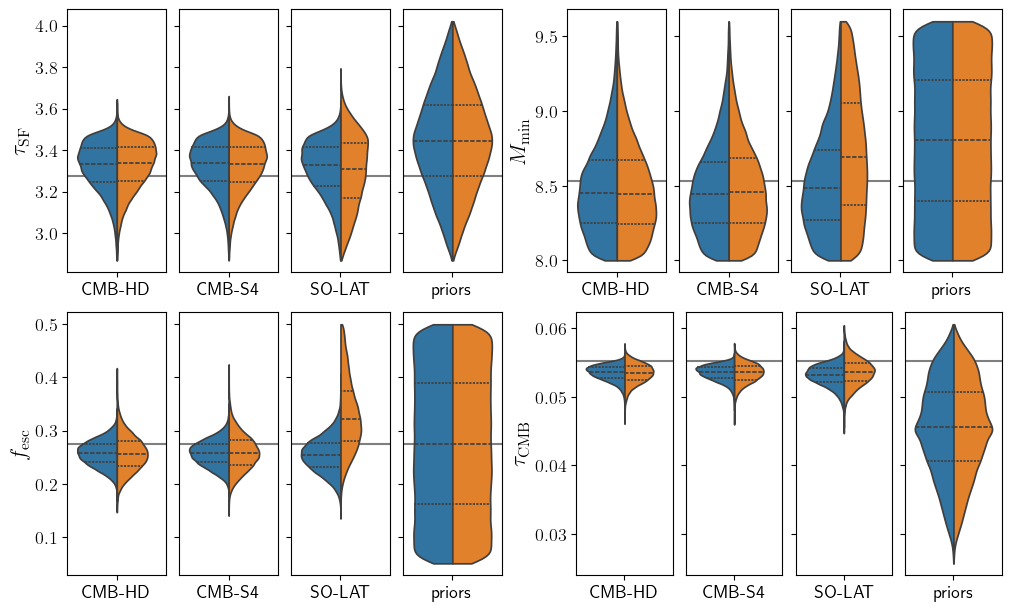

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6), constrained_layout=True)
subfigs = fig.subfigures(2, 2, wspace=0.0)
[subf.subplots_adjust(wspace=0.0) for subf in subfigs.flatten()]
# subfigs[1].subplots_adjust(wspace=0)

sn = config.sn
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]

def plot_violins(axs, df, pname, pval, xlabel=None):
    for i_survey, survey in enumerate(survey_labels):
        # if xlabel != None:
        #     xlabel = survey
        
        ax = axs[i_survey]
        ax.axhline(pval, color='black', alpha=.5, zorder=0)
        # Filter to only the two main groups
        df_subset = df_samples[
            (df_samples["parameter"] == pname) &
            # (df_samples["rundir"] == 'productionruns5_mechaemu') &
            (df_samples["survey"] == survey) &
            (df_samples["setup"] == 'noiseless') &
           (df_samples["rundir"].isin([rundirs[2],rundirs[3]]))].copy()
    
        # Create a new column for combined group/subgroup label
        df_subset["group_subgroup"] = survey #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
        # Plot each group_subgroup as a separate category on the x-axis
        sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
                       inner='quart', hue="rundir", x="group_subgroup", y="value", ax=ax)

        ax.set_xlabel(None)
        ax.set_ylabel('')

        # if i_param == 0:
        #     ax.set_title(f"{survey}")
        ax.set_ylabel(astro_pnames_formatted[2+i], fontsize=16)
        ax.get_legend().remove()

subfigs = subfigs.flatten()
for i, pname in enumerate(dim_labels):
    axs = subfigs[i].subplots(1, 4, sharey='row')
    xlabel = None
    if i > 1:
        xlabel = 'survey'
    plot_violins(axs, df, pname, true_params[2+i])

# plt.tight_layout()
# plt.savefig("violins.png", dpi=300, bbox_inches='tight')


productionruns2_mechaemu
productionruns5_mechaemu


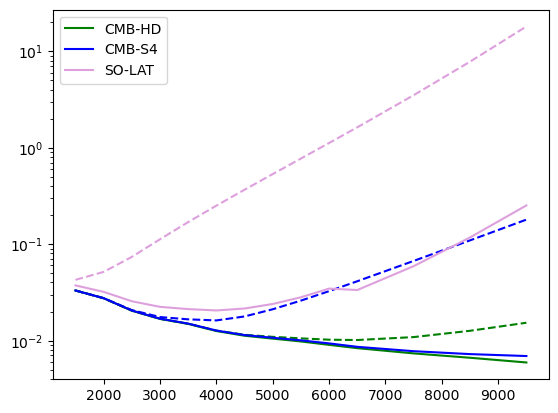

In [66]:
for idir, rundir in enumerate(rundirs[:2]):
    print(rundir)
   # chains_surveys = []
    for isur, survey in enumerate(survey_labels):
     #   chains = []
        path = f"{base_dir}/inference/{rundir}/{survey}/noiseless"
        if os.path.exists(f"{path}/saved_chains.h5"):
            data = np.load(f"{path}/data.npz")

            if idir == 0:
                ls = '--'
                label = None
            if idir == 1:
                ls = '-'
                label = survey

            plt.semilogy(data['ells'], data['err'], color=colors[isur], ls=ls, label=label)

plt.legend()


In [51]:
s, l = utils.load_samples(f"{base_dir}/inference/productionruns5_mechaemu/CMB-HD/noiseless")
s2, l = utils.load_samples(f"{base_dir}/inference/{rundirs[0]}/CMB-HD/noiseless")

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns5_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...


In [ ]:
data = f"{base_dir}/inference/productionruns5_addhksz/CMB-HD/noiseless")

In [15]:
s, l = utils.load_samples(f"{base_dir}/inference/productionruns5_mechaemu/CMB-HD/noiseless")
s.shape

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns5_mechaemu/CMB-HD/noiseless...


(1200, 4)

In [47]:
s2[:,:-2].shape

(120000, 3)

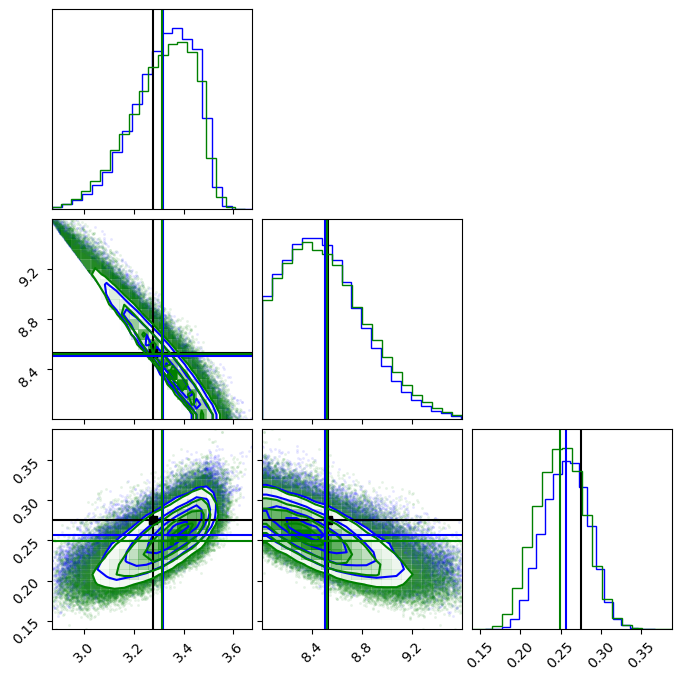

In [55]:
fig = corner.corner(s[:,:-1], color='blue', truths=df.loc[config.sn].to_numpy()[2:], truth_color='black')
fig = corner.corner(s2[:,:-1], color='green', fig=fig)

ndim = 3
axes = np.array(fig.axes).reshape((ndim, ndim))

plot_vlines(s.mean(axis=0)[:-1], axes, color='blue')
plot_vlines(s2.mean(axis=0)[:-1], axes, color='green')

In [194]:
# 95% confidence interval
np.percentile(posterior_A, [2.5, 97.5])

array([0.04359281, 0.05337768, 0.03270758, ..., 0.03909752, 0.03866439,
       0.04055832], shape=(24000,))

In [191]:
df0 = df_samples[df_samples['rundir'] == df_samples['rundir'].unique()[0]]
df1 = df0[df0['survey'] == 'CMB-HD']
df2 = df1[df1['setup'] == 'noiseless']
df2

,value,parameter,rundir,survey,setup,sample_index
0,3.891974,tau,productionruns2_mechaemu,CMB-HD,noiseless,0
1,8.048890,Mmin,productionruns2_mechaemu,CMB-HD,noiseless,0
2,0.377278,fesc,productionruns2_mechaemu,CMB-HD,noiseless,0
3,0.043593,A,productionruns2_mechaemu,CMB-HD,noiseless,0
4,0.043593,tau_CMB,productionruns2_mechaemu,CMB-HD,noiseless,0
...,...,...,...,...,...,...
119995,3.356403,tau,productionruns2_mechaemu,CMB-HD,noiseless,23999
119996,8.811454,Mmin,productionruns2_mechaemu,CMB-HD,noiseless,23999
119997,0.114871,fesc,productionruns2_mechaemu,CMB-HD,noiseless,23999
119998,0.040558,A,productionruns2_mechaemu,CMB-HD,noiseless,23999


In [192]:
s.shape

(120000, 4)

In [ ]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(5,12))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for run_i, survey_chains in enumerate(chains_runs[0]):
    print(len(survey_chains))
    print(f"run_i={run_i}")
    for survey_i, chain in enumerate(survey_chains[2:]):
        print(f"survey_i={survey_i}")
    # lp = lps[n]
    # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin
    
        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True
    
        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())
    
        for ip, p in enumerate(true_params[2:]):
            ax[ip,run_i].axhline(p, alpha=.2, color='black')
            ax[ip,run_i].violinplot(chain[:,ip], [survey_i+.5], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            if ip == len(true_params[2:]) -1:
                ax[ip,0].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)
            else:
                ax[ip,0].set_ylabel(astro_pnames_formatted[2+ip], fontsize=16)
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,run_i].set_xticks(np.arange(1, len(setups[2:])+.5))
    ax[3,i].set_xticklabels([f"{setup}" for si, setup in enumerate(setups[2:])])
        
    ax[0,run_i].set_title(f'{survey_labels[run_i]}', fontsize=12)

    fig.savefig('violins.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


In [20]:
survey_colors = ['#2ff3e0', '#cbfbf8', '#f8d210', '#fdf4aa', '#fa26a0', '#fdb9d8']

0
1
2
3
4
5


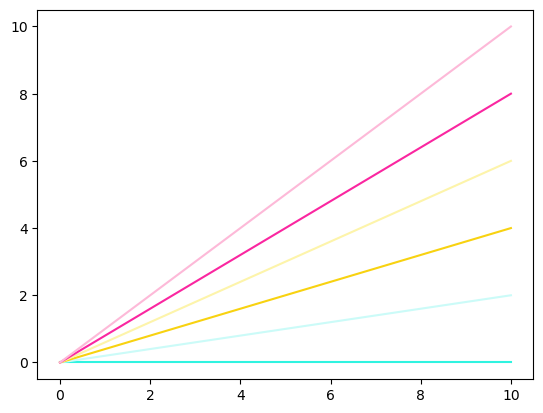

In [21]:
x = np.linspace(0,10)

for i, col in enumerate(survey_colors):
    print(i)
    plt.plot(x, i * .2 * x, color=col)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


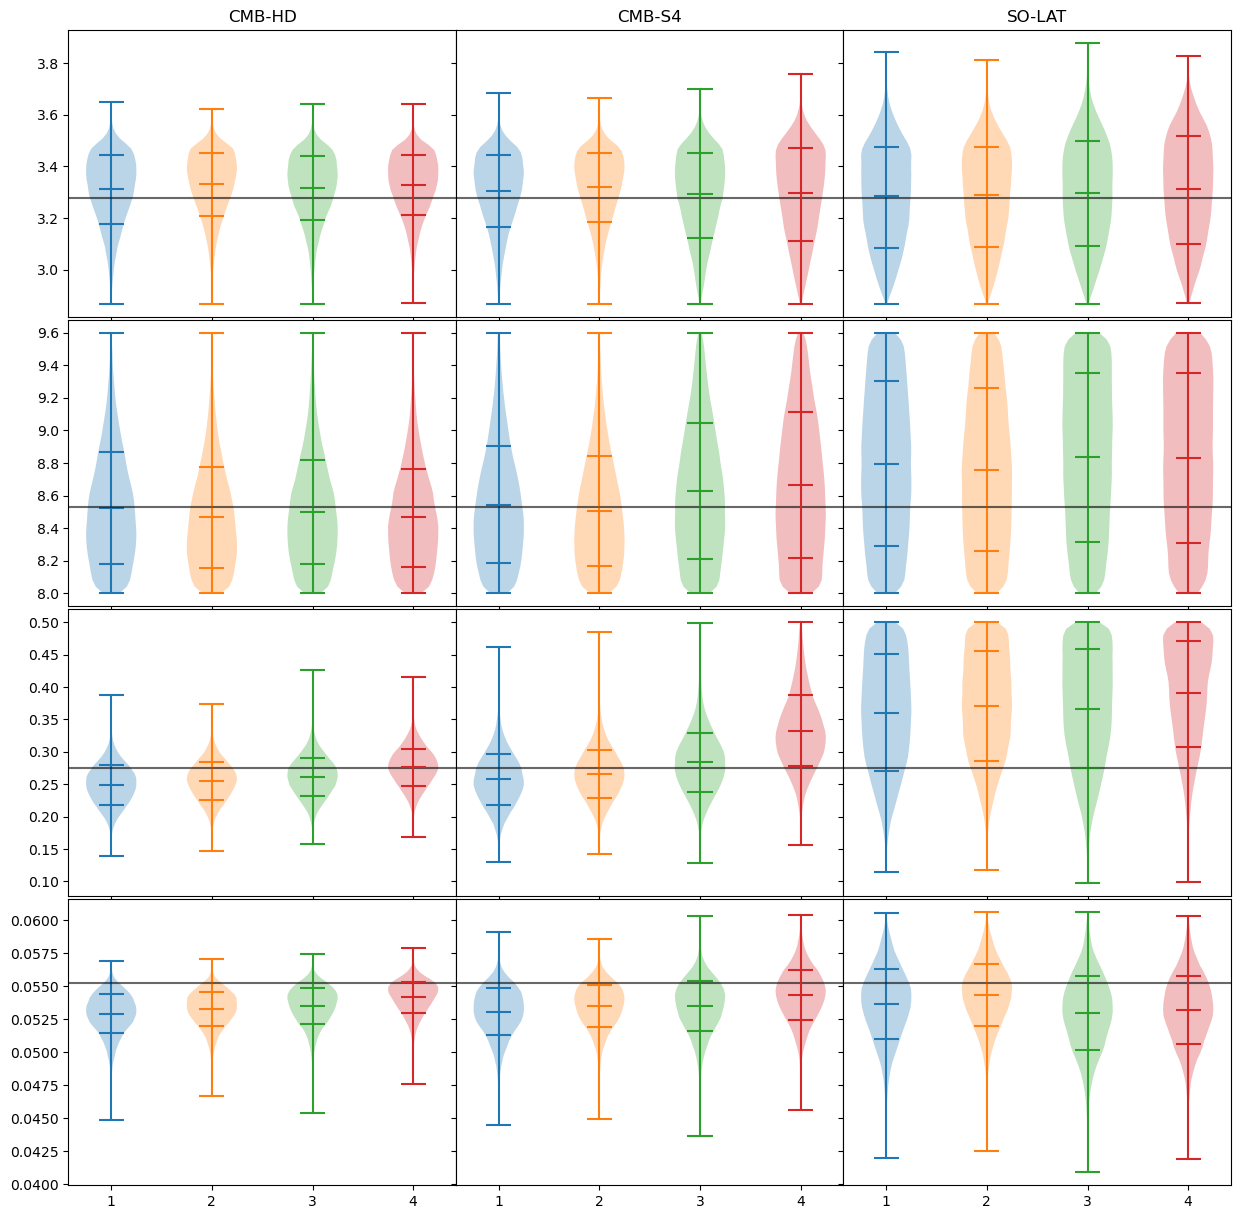

In [82]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

chains_all = chains_runs[0]
for i, chains in enumerate(chains_all):
    for j, chain in enumerate(chains):
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [j+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    # ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{survey_labels[i]}', fontsize=12)


In [34]:
def plot_corner(samples, axes, label=None, **kwargs):
    x, y, z, t = samples.T

    sns.kdeplot(x=x, y=y, levels=3,
            ax=ax[1,0], **kwargs)
    sns.kdeplot(x=y, y=z, levels=3,
                ax=ax[2,1], **kwargs)
    sns.kdeplot(x=x, y=z, levels=3,
                ax=ax[2,0], **kwargs)

    sns.kdeplot(x=x, ax=ax[0,0], label=label, **kwargs)
    sns.kdeplot(x=y, ax=ax[1,1], **kwargs)
    sns.kdeplot(x=z, ax=ax[2,2], **kwargs)

    return axes

In [40]:
len(chains_runs[-1])

3

In [51]:
for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups[2:]):

'productionruns3_mechaemu_simu10818'

In [29]:
len(chains_runs[0][0])

4

In [32]:
for i, chains in enumerate(chains_runs[0]):
    for j, chain in enumerate(chains[2:]):
        print(2*i+j)

0
1
2
3
4
5


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)
(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


...

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(19200, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


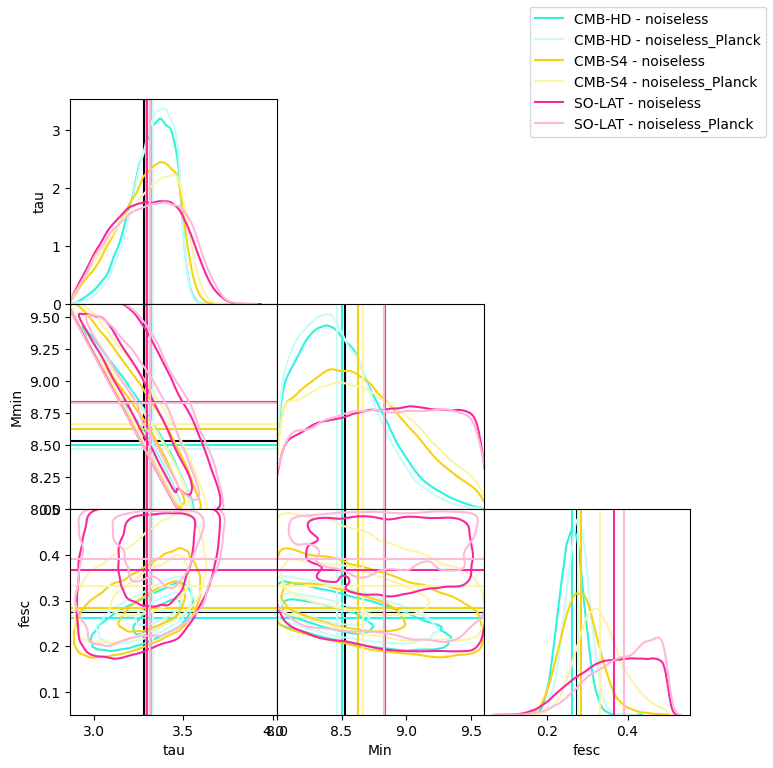

In [35]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

line_kwargs = {}

line_kwargs['color'] = 'black'

sn = config.sn
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]
plot_vlines(true_params[2:], ax, **line_kwargs)

for i, chains in enumerate(chains_runs[0]):
    for j, chain in enumerate(chains[2:]):
        print(chain.shape)
        line_kwargs['color'] = survey_colors[2*i+j]
        samples = make_tauchains(chain, truths=df.loc[sn].to_dict())
        plot_corner(samples, ax, label=f'{survey_labels[i]} - {setups[j]}', **line_kwargs)
        plot_vlines(np.mean(samples, axis=0), ax, **line_kwargs)

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)
(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(19200, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


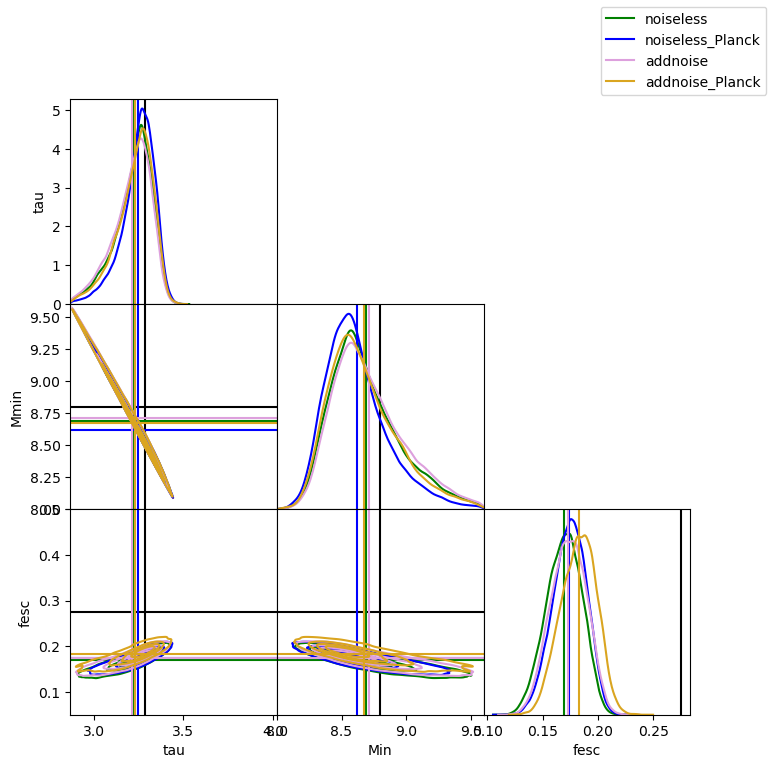

In [53]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

line_kwargs = {}

line_kwargs['color'] = 'black'

sn = '10818'
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]
plot_vlines(true_params[2:], ax, **line_kwargs)

for i, chain in enumerate(chains_runs[-1][0]):
    print(chain.shape)
    line_kwargs['color'] = colors[i]
    samples = make_tauchains(chain, truths=df.loc[sn].to_dict())
    plot_corner(samples, ax, label=f'{setups[i]}', **line_kwargs)
    plot_vlines(np.mean(samples, axis=0), ax, **line_kwargs)

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

In [ ]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)


plot_vlines(true_params[2:], ax, color='black')

sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
             color='grey', ax=ax[1,0], ls='-')
sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
             color='grey', ax=ax[2,1], ls='--')
sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
             color='grey', ax=ax[2,0], ls='--')

sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='gray', label='previous run')
sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='gray')
sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='gray')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,1], levels=5,
             color=colors[4], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,1], levels=5,
             color='black', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_prior[:,1], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], ax=ax[0,0], ls='-', color='black', label=f'3 param prior')
sns.kdeplot(x=samples_prior[:,1], ax=ax[1,1], ls='-', color='black')
sns.kdeplot(x=samples_prior[:,2], ax=ax[2,2], ls='-', color='black')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], ax=ax[0,0], ls='-', color=colors[4], label='tau/Mmin/fesc')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], ax=ax[1,1], ls='-', color=colors[4])
sns.kdeplot(x=samples_tau_Mmin_fesc[:,2], ax=ax[2,2], ls='-', color=colors[4])

sns.kdeplot(x=samples_tau_Mmin[:,0], ax=ax[0,0], color=colors[0], label='tau/Min')
sns.kdeplot(x=samples_tau_Mmin[:,1], ax=ax[1,1], color=colors[0])
sns.kdeplot(x=samples_tau_Mmin[:,0], y=samples_tau_Mmin[:,1], levels=5, ax=ax[1,0], color=colors[0])

sns.kdeplot(x=samples_Mmin_fesc[:,0], ax=ax[1,1], ls='--', color=colors[2], label='Mmin/fesc')
sns.kdeplot(x=samples_Mmin_fesc[:,1], ax=ax[2,2], ls='--', color=colors[2],)
sns.kdeplot(x=samples_Mmin_fesc[:,0], y=samples_Mmin_fesc[:,1], color=colors[2], levels=5, ax=ax[2,1], ls='--')

sns.kdeplot(x=samples_tau_fesc[:,0], ax=ax[0,0], ls='--', color=colors[3], label='tau/fesc')
sns.kdeplot(x=samples_tau_fesc[:,1], ax=ax[2,2], ls='--', color=colors[3])
sns.kdeplot(x=samples_tau_fesc[:,0], y=samples_tau_fesc[:,1], levels=5, color=colors[3], ax=ax[2,0], ls=':')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,1], levels=5,
             color=colors[5], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], ax=ax[0,0], ls='-', color=colors[5], label=f'3% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], ax=ax[1,1], ls='-', color=colors[5])
sns.kdeplot(x=samples_Mmin_prior_3percent[:,2], ax=ax[2,2], ls='-', color=colors[5])


sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,1], levels=5,
             color=colors[6], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], ax=ax[0,0], ls='-', color=colors[6], label=f'2% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], ax=ax[1,1], ls='-', color=colors[6])
sns.kdeplot(x=samples_Mmin_prior_2percent[:,2], ax=ax[2,2], ls='-', color=colors[6])


sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,1], levels=5,
             color='violet', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], ax=ax[0,0], ls='-', color='violet', label=f'1% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], ax=ax[1,1], ls='-', color='violet')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,2], ax=ax[2,2], ls='-', color='violet')

s, l = utils.load_samples(f"{base_dir}/inference/productionruns_justpriors/CMB-HD")

# sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
#              color='red', ax=ax[1,0], ls='-')
# sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
#              color='red', ax=ax[2,1], ls='--')
# sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
#              color='red', ax=ax[2,0], ls='--')

# sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='red', label=f'prior previous')
# sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='red')
# sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='red')

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            label = ''
            if i == 0:
                label = 'individual fit'
            sns.kdeplot(single_samples[i].flatten(), ax=axes, color=colors[1], zorder=0, label=label)
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

In [107]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_all_samples(base_dir, rundirs, survey_labels, setups, pnames, config, utils, make_tauchains):
    rows = []

    for rundir in rundirs:
        for survey in survey_labels:
            for setup in setups:
                if survey == 'priors':
                    path = f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/{setup}"
                else:
                    path = f"{base_dir}/inference/{rundir}/{survey}/{setup}"

                chain_file = f"{path}/saved_chains.h5"
                if os.path.exists(chain_file):
                    print(f"Loading samples for rundir={rundir}, survey={survey}, setup={setup}")
                    samples, l = utils.load_samples(path)
                    
                    # Modify samples as needed
                    samples_wtau = make_tauchains(samples[:, :3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
                    full_samples = np.concatenate([samples_wtau, samples[:, 3:]], axis=1)
                    
                    n_samples, n_params = full_samples.shape
                    
                    for i_sample in range(n_samples):
                        for dim_idx in range(n_params):
                            rows.append({
                                "value": full_samples[i_sample, dim_idx],
                                "parameter": pnames[dim_idx],
                                "rundir": rundir,
                                "survey": survey,
                                "setup": setup,
                                "sample_idx": i_sample
                            })

    df_samples = pd.DataFrame(rows)
    return df_samples

def plot_pairplot(df_samples, rundir_filter, setup_filter, param_order, alpha=0.1, s=5):
    # Filter for rundir and setup
    df_filtered = df_samples[
        (df_samples['rundir'] == rundir_filter) &
        (df_samples['setup'] == setup_filter)
    ].copy()

    if df_filtered.empty:
        print(f"No data found for rundir={rundir_filter}, setup={setup_filter}")
        return

    # Pivot: each row = sample_idx + survey; columns = parameters
    df_wide = df_filtered.pivot_table(
        index=['sample_idx', 'survey'],
        columns='parameter',
        values='value'
    ).reset_index()

    # Check which params exist
    params_in_df = [p for p in param_order if p in df_wide.columns]
    if not params_in_df:
        print("No parameters found to plot.")
        return

    g = sns.pairplot(
        df_wide,
        hue='survey',
        vars=params_in_df,
        kind='kde',        # or 'scatter', 'hist', etc.
        diag_kind='kde',
        corner=True,    
        plot_kws=dict(
        alpha=0.3,
        fill=True,
        levels=[0.68, 0.95, 0.997]
    ),
    diag_kws=dict(
        fill=True,
        levels=[0.68, 0.95, 0.997]
    )
    )

    for i, param in enumerate(astro_pnames_formatted[2:]):
        g.axes[i, 0].set_ylabel(param)
        g.axes[-1, i].set_xlabel(param)

    return g

# === Usage example ===

rundirs = ['productionruns2_mechaemu',
           'productionruns5_mechaemu',
           'productionruns6_mechaemu',
           'productionruns6_addhksz']

survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT', 'priors']

setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

# Your param names (make sure this matches your samples shape)
pnames = [*df.columns[2:], 'tau_CMB', 'A', 'A_hksz']

# Load everything once
# df_samples = load_all_samples(base_dir, rundirs, survey_labels, setups, pnames, config, utils, make_tauchains)

# # Now plot all samples for one rundir and setup, comparing surveys:
# plot_pairplot(
#     df_samples,
#     rundir_filter='productionruns6_addhksz',
#     setup_filter='noiseless',
#     param_order=pnames,
#     alpha=0.1
# )


In [110]:
from alfred.parameters import astro_pnames_formatted

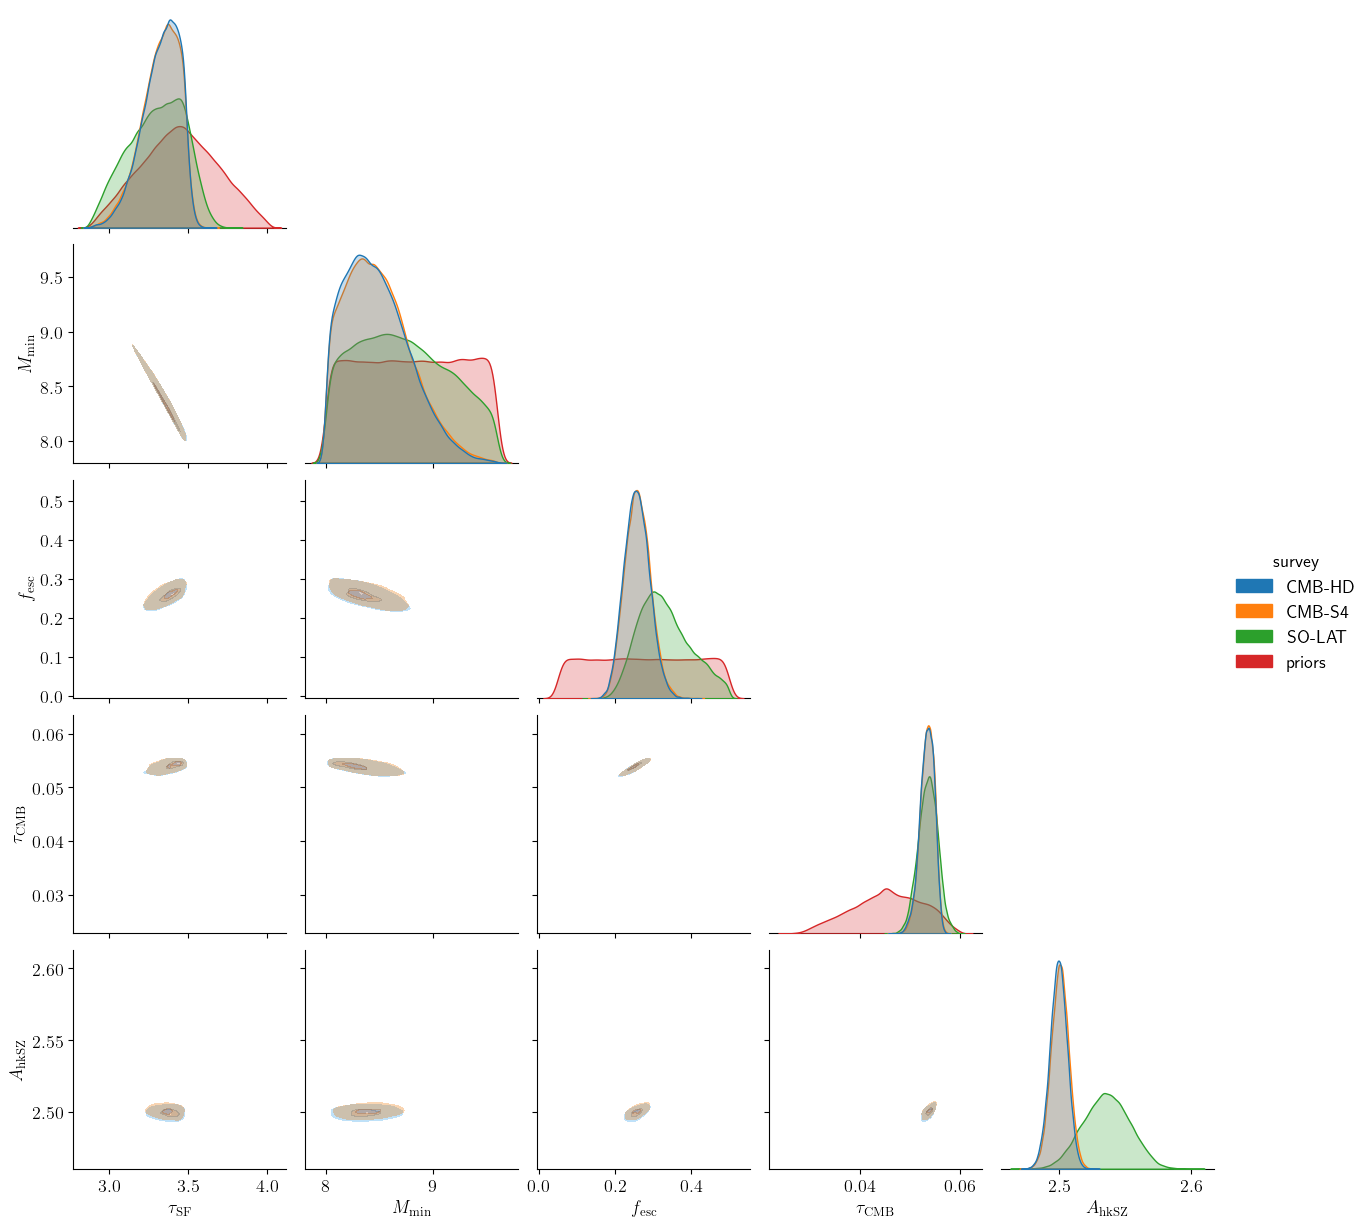

In [111]:
# Now plot all samples for one rundir and setup, comparing surveys:
g = plot_pairplot(
    df_samples,
    rundir_filter='productionruns6_addhksz',
    setup_filter='noiseless',
    param_order=[*df.columns[2:], 'tau_CMB', 'A_hksz'],
)


In [152]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def compute_kde_levels(x, y, probs=[0.68, 0.95, 0.997], gridsize=100):
    """Compute KDE contour heights that enclose given cumulative probabilities."""
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    
    # Grid for evaluation
    X, Y = np.meshgrid(
        np.linspace(x.min(), x.max(), gridsize),
        np.linspace(y.min(), y.max(), gridsize)
    )
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Compute contour levels for desired probability mass
    Z_sorted = np.sort(Z.ravel())[::-1]   # descending
    Z_cumsum = np.cumsum(Z_sorted)
    Z_cumsum /= Z_cumsum[-1]              # normalize to 1
    
    levels = [Z_sorted[np.searchsorted(Z_cumsum, p)] for p in probs]
    return levels

def plot_pairplot(df_samples, rundir_filter, setup_filter, param_order, astro_pnames_formatted, alpha=0.1, s=5):
    # Filter for rundir and setup
    df_filtered = df_samples[
        (df_samples['rundir'] == rundir_filter) &
        (df_samples['setup'] == setup_filter)
    ].copy()

    if df_filtered.empty:
        print(f"No data found for rundir={rundir_filter}, setup={setup_filter}")
        return

    # Pivot: each row = sample_idx + survey; columns = parameters
    df_wide = df_filtered.pivot_table(
        index=['sample_idx', 'survey'],
        columns='parameter',
        values='value'
    ).reset_index()

    # Check which params exist
    params_in_df = [p for p in param_order if p in df_wide.columns]
    if not params_in_df:
        print("No parameters found to plot.")
        return

    # # Compute KDE levels for each off-diagonal pair
    # kde_levels = {}
    # for i, p1 in enumerate(params_in_df):
    #     for j, p2 in enumerate(params_in_df):
    #         if i >= j:
    #             continue  # only off-diagonal
    #         levels = compute_kde_levels(
    #             df_wide[p1].values,
    #             df_wide[p2].values
    #         )
    #         kde_levels[(p1, p2)] = levels

    # Plot pairplot
    g = sns.pairplot(
        df_wide,
        hue='survey',
        vars=params_in_df,
        kind='kde',
        diag_kind='kde',
        corner=True,
        plot_kws=dict(alpha=alpha, fill=True),   # we will override levels below
        diag_kws=dict(fill=True)
    )

        # Override each off-diagonal panel with correct probability-mass levels
    for i, p1 in enumerate(params_in_df):
        for j, p2 in enumerate(params_in_df):
            if i <= j:  # only lower triangle in corner=True
                continue
            ax = g.axes[i, j]
            for coll in ax.collections:
                coll.remove()
    
            for k, survey in enumerate(df_wide['survey'].unique()):
                print(f"On survey {survey}")
                print(f"For params: {p1}, {p2}")
                mask = df_wide['survey'] == survey
                x = df_wide.loc[mask, p2]
                y = df_wide.loc[mask, p1]

                # print('CHECKING HERE')
                # print(df_wide.loc[mask, p2].isna().sum())
                # print(np.isinf(df_wide.loc[mask, p2]['value']).sum())
                # print()

    
                # Build KDE
                values = np.vstack([x, y])
                kde = gaussian_kde(values)
    
                # Grid for contour
                X, Y = np.meshgrid(
                    np.linspace(x.min(), x.max(), 100),
                    np.linspace(y.min(), y.max(), 100)
                )
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = kde(positions).reshape(X.shape)
    
                # Compute KDE levels
                sorted_Z = np.sort(Z.ravel())[::-1]
                cdf = np.cumsum(sorted_Z)
                cdf /= cdf[-1]
                levels = [sorted_Z[np.searchsorted(cdf, p)] for p in [0.68, 0.95, 0.997]]

                print(levels)
                # Plot contour
                ax.contour(
                    X, Y, Z,
                    levels=levels,
                    colors=[sns.color_palette()[k]],
                    alpha=alpha
                )

    # Update axis labels
    for i, param in enumerate(astro_pnames_formatted[:len(params_in_df)]):
        g.axes[i, 0].set_ylabel(param)
        g.axes[-1, i].set_xlabel(param)

    return g


On survey CMB-HD
For params: Mmin, tau
[np.float64(7.61065016030473), np.float64(1.2310418933039997), np.float64(0.10073661660946197)]


ValueError: Contour levels must be increasing

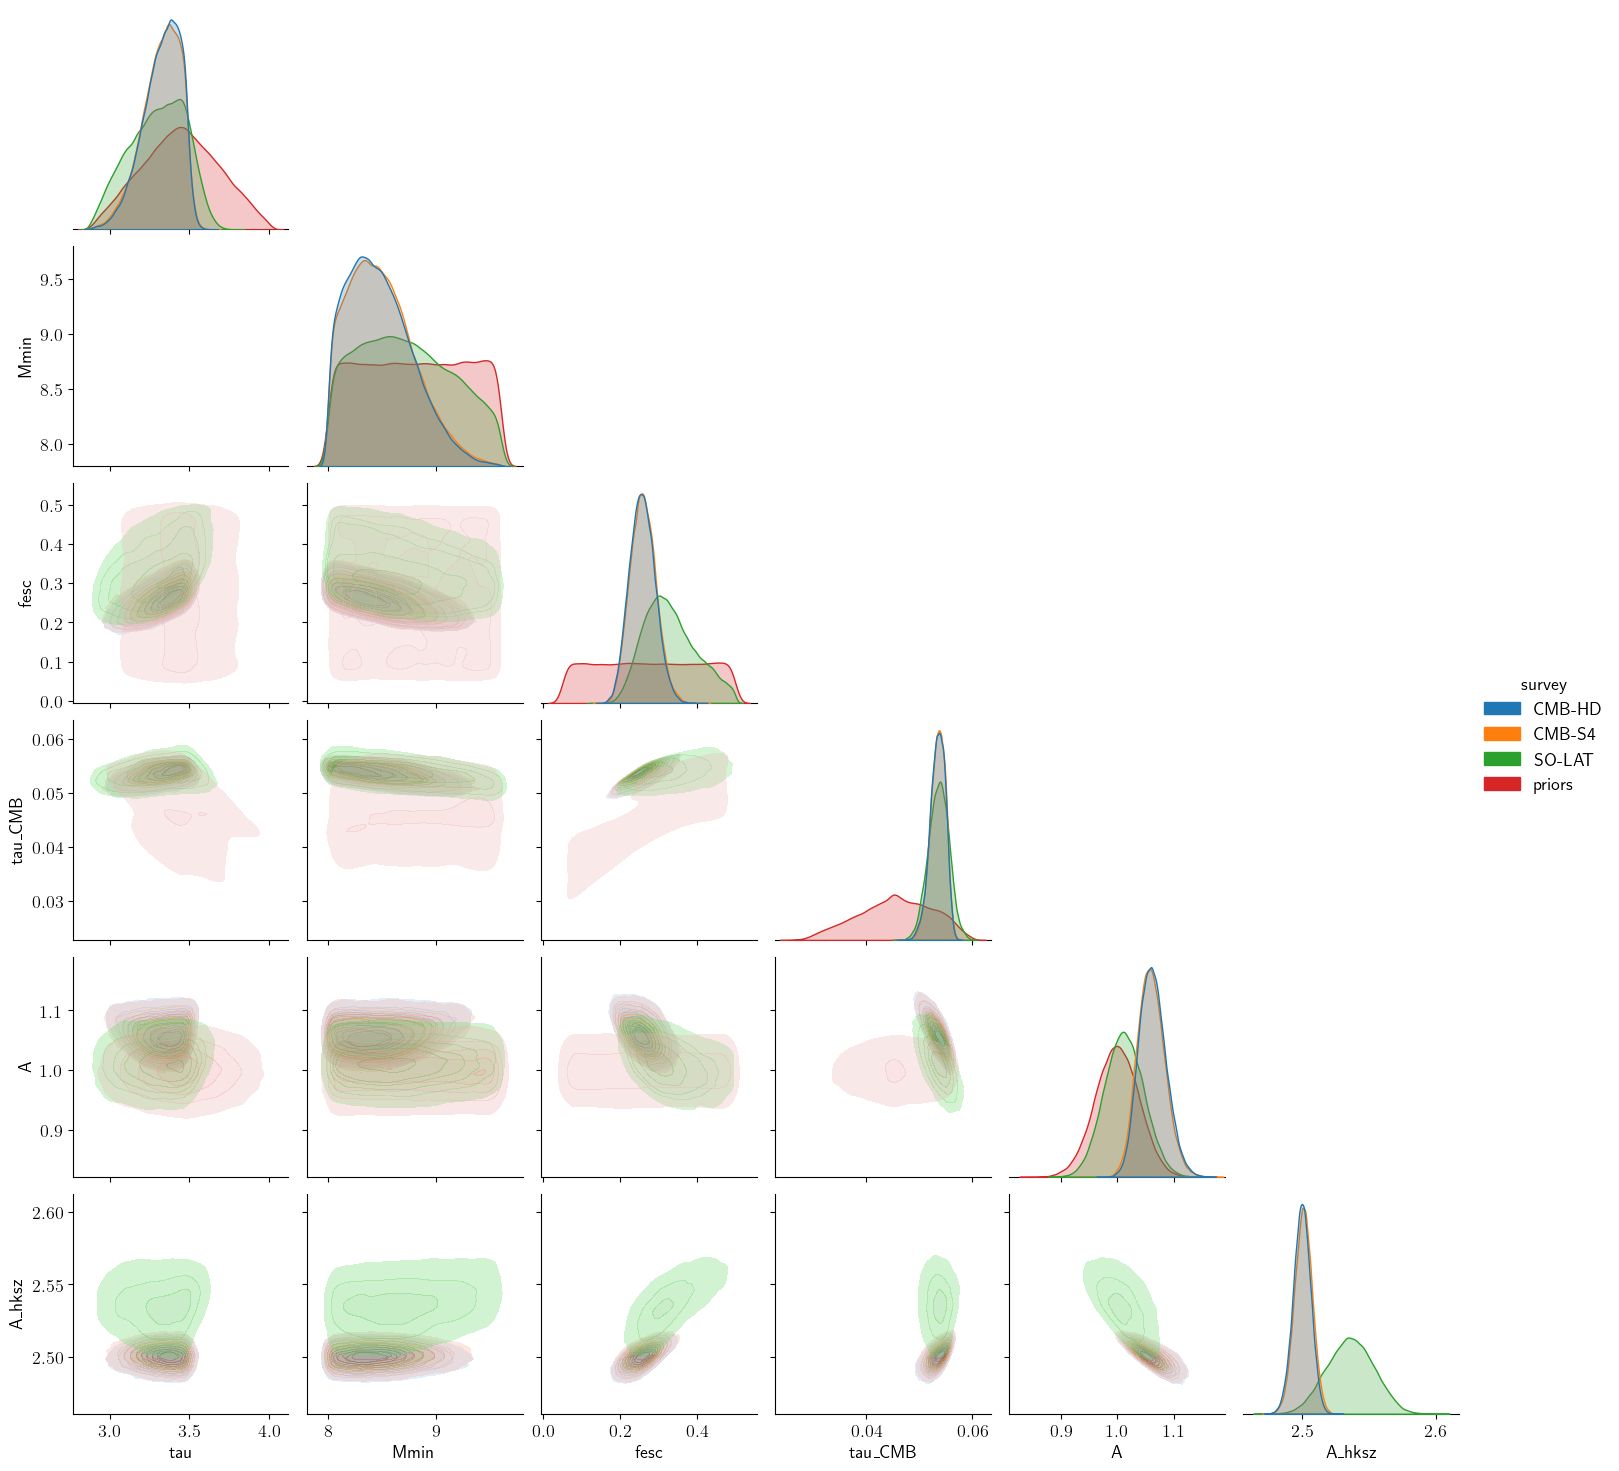

In [153]:
g = plot_pairplot(
    df_samples=df_samples,
    rundir_filter='productionruns6_addhksz',
    setup_filter='noiseless',
    param_order=pnames,                   # list of parameter names matching your df columns
    astro_pnames_formatted=astro_pnames_formatted[2:],  # LaTeX labels
    alpha=0.3,                            # transparency of contours                                  # (optional, mostly used for scatter points if needed)
)